In [17]:
import numpy as np
data = np.load('mnist.npz')
print(data.files)  


['x_test', 'x_train', 'y_train', 'y_test']


In [18]:
for name in data.files:
    print(name, data[name])
    print(np.size(data)) 

x_test [[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
4
x_train [[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 

In [19]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

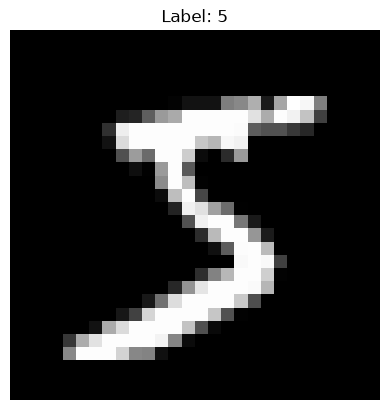

In [20]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [21]:
print(x_train.shape)

(60000, 28, 28)


In [22]:
import os
from PIL import Image
import numpy as np

image = Image.open("images/image.png").convert("RGB") 
image = np.array(image)/255
noise = np.random.normal(0, 0.1, image.shape)

sigma = 1

noisy_image = image + sigma * noise


## Verifying the target score, and its dimensions. 

In [23]:
target_score = -(noise/sigma)
print(target_score)
print(target_score.mean())
print(target_score.std())
print(target_score.shape)

[[[-0.00549998 -0.216992   -0.13598754]
  [-0.15199793 -0.04227268 -0.1019369 ]
  [ 0.06774534  0.08542125  0.07996705]
  ...
  [-0.00504073  0.07726069  0.03441513]
  [ 0.0178798   0.11113681  0.11615239]
  [-0.20431066 -0.05005988  0.09836386]]

 [[-0.02445657  0.06943779 -0.0338207 ]
  [-0.02514421  0.24330422 -0.11846191]
  [-0.20113536  0.0514801   0.08632522]
  ...
  [ 0.01346086 -0.14253393  0.06029001]
  [-0.01374873 -0.00558336  0.13048565]
  [ 0.10571864 -0.09898471 -0.01403624]]

 [[-0.05216083  0.02287527  0.00219602]
  [-0.13292424  0.01936273  0.06684127]
  [ 0.11656165 -0.07624096  0.00307681]
  ...
  [ 0.1748231   0.01849837 -0.07401651]
  [-0.06651624  0.08826762  0.18575796]
  [-0.14663829 -0.15163294  0.00835858]]

 ...

 [[ 0.10492287 -0.13305115 -0.10842807]
  [ 0.06328158 -0.01780353 -0.00030294]
  [-0.01297519  0.11918843 -0.170123  ]
  ...
  [-0.13229309 -0.03512938  0.12057174]
  [-0.0103873   0.06312995  0.05983384]
  [ 0.03220236 -0.0700246  -0.25846905]]

 [

## Forward equation verification

In [24]:
reconstruct_noisy = image + sigma*noise
difference = noisy_image - reconstruct_noisy 
print(np.max(np.abs(difference))) 

0.0


## Verifying target score 

In [25]:
score_from_noise = -(noise/sigma)
score_from_images = -(noisy_image - image)/(sigma**2)
score_difference = score_from_noise - score_from_images 
print(np.max(np.abs(score_difference)))

1.1102230246251565e-16


## Checking if the statistics make sense

In [26]:
print("Target score mean:", target_score.mean())
print("Target score std:", target_score.std())
print("Expected standard deviation:", 1/sigma)

Target score mean: -0.00011594591412971386
Target score std: 0.10022439436136941
Expected standard deviation: 1.0


## Checking the noise levels, all 6 of them. 
## sigma = [0.01,0.05,0.1,0.2,0.5,1]

In [27]:
sigmas = [0.01,0.05,0.1,0.2,0.5,1]
for sigma in sigmas:
  noise = np.random.normal(0,1, image.shape)
  noisy_image= image + sigma*noise
  target_score = -(noise/sigma)
  print(
    f"sigma = {sigma:.2f}|"
    f"noise std = {noise.std():.4f}|"
    f"score std = {target_score.std():.4f}|"
    f"expected std = {1/sigma:.4f}"
  )

sigma = 0.01|noise std = 0.9996|score std = 99.9565|expected std = 100.0000
sigma = 0.05|noise std = 1.0010|score std = 20.0205|expected std = 20.0000
sigma = 0.10|noise std = 0.9992|score std = 9.9920|expected std = 10.0000
sigma = 0.20|noise std = 0.9987|score std = 4.9933|expected std = 5.0000
sigma = 0.50|noise std = 0.9994|score std = 1.9989|expected std = 2.0000
sigma = 1.00|noise std = 1.0002|score std = 1.0002|expected std = 1.0000


In [28]:
input_size = np.prod(image.shape)
print("Input size:", input_size)

Input size: 477303


In [29]:
x = noisy_image.flatten()

In [30]:
def training_example(image, sigma):
  noise = np.random.normal(0,1, image.shape)
  noisy_image= image + sigma*noise 
  target_score = -(noise/sigma)
  return noisy_image, sigma, target_score

sigma = 0.1
noisy_image, sigma, target_score = training_example(image, sigma)
print("Noisy image shape:", noisy_image.shape)
print("Sigma:", sigma)
print("Target score shape:", target_score.shape)  

Noisy image shape: (409, 389, 3)
Sigma: 0.1
Target score shape: (409, 389, 3)


## This is the beginning of the CNN. Layer by layer using PyTorch

In [31]:
import torch
import torch.nn as nn

OSError: [WinError 4551] An Application Control policy has blocked this file. Error loading "c:\Users\Reneiloe Nyathela\OneDrive\Desktop\personal-brand-site\.venv\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [ ]:
conv1 = nn.Conv2d(
  in_channels=4, # Input 4 (RGB + noise) channels. The input image has 3 channels (RGB) and we add 1 channel for the noise.
  out_channels=32, # This allows the NN to look at 32 different things. Without us telling it what to actually look for
  kernel_size=3, # Each filter looks at small 3by3 patches. 
  padding=1
)

NameError: name 'nn' is not defined

In [ ]:
noisy_tensor = torch.tensor(noisy_image, dtype=torch.float32) #This converts the noisy image into a pytorch tensor

sigma_channel = torch.full(
  (409,389), sigma , dtype = torch.float32
) # This adds sigma(noises) as the 4th channel

cnn_input = torch.cat(
  [noisy_tensor, sigma_channel.unsqueeze(2)],
  dim = 2
) # This combines the RGB with the noise (RGB+noise)

print(cnn_input.shape)


torch.Size([409, 389, 4])


## Changing it into a format PyTorch expects and understands

In [ ]:
cnn_input = cnn_input.permute(2,0,1) 
cnn_input = cnn_input.unsqueeze(0)
print(cnn_input.shape)

torch.Size([1, 4, 409, 389])


## This next step passes it through the first convulation

In [ ]:
output = conv1(cnn_input)
print(output.shape)

torch.Size([1, 32, 409, 389])


## Adding the ReLU : Activation function

In [ ]:
relu = nn.ReLU()
output_relu = relu(output)
print(output_relu.shape)

torch.Size([1, 32, 409, 389])


## What the ReLU actually did is:

In [ ]:
print("Before ReLU:")
print(output.min(), output.max())

print("After ReLU:")
print(output_relu.min(), output_relu.max())

Before ReLU:
tensor(-1.0322, grad_fn=<MinBackward1>) tensor(1.5175, grad_fn=<MaxBackward1>)
After ReLU:
tensor(0., grad_fn=<MinBackward1>) tensor(1.5175, grad_fn=<MaxBackward1>)


## Second Convulation : # The first convulation took 4 channels to 32 feature maps. Now the second convulation will take 32 feature maps and process them further

In [ ]:
conv2 = nn.Conv2d(
  in_channels = 32,
  out_channels = 32,
  kernel_size = 3,
  padding = 1
)


In [ ]:
output2 = conv2(output_relu) # This passes our ReLU output throught the second convulation
print(output2.shape)


torch.Size([1, 32, 409, 389])


## Second ReLU

In [ ]:
relu2 = nn.ReLU()
output_relu2 = relu2(output2)
print(output_relu2.shape)

torch.Size([1, 32, 409, 389])


## Now we need a final convulation that properly converts 32 to 3. To better match the RGB. 

In [ ]:
# Third convulation
conv3 = nn.Conv2d(
  in_channels = 32,
  out_channels = 3,
  kernel_size = 3,
  padding = 1
)

In [ ]:
predicted_score = conv3(output_relu2)
print(predicted_score.shape)

torch.Size([1, 3, 409, 389])


## Our nextwork in just a few computations has gone: (1,4,409,389)->(1,32,409,389)->(1,32,409,389)->(1,3,409,389) . The final 3 corresponds to the three compomenents of the predicted score

In [ ]:
class ScoreNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(
      in_channels = 4,
      out_channels = 32,
      kernel_size = 3,
      padding = 1
    )
    self.relu1 = nn.ReLU()

    self.conv2 = nn.Conv2d(
      in_channels = 32,
      out_channels = 32,
      kernel_size = 3,
      padding = 1
    )

    self.relu2 = nn.ReLU()

    self.conv3 = nn.Conv2d(
      in_channels = 32,
      out_channels = 3,
      kernel_size = 3,
      padding = 1
    )

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu1(x)
    x = self.conv2(x)
    x = self.relu2(x)
    x = self.conv3(x)
    return x



In [ ]:
model = ScoreNetwork()

In [ ]:
predicted_score = model(cnn_input)
print(predicted_score.shape)

torch.Size([1, 3, 409, 389])


## Mean square error (MSE) and converting the target score into the same PyTorch shape

In [ ]:
# PyTorch has/expects (batch, channels, height, width)

target_tensor = torch.tensor(
  target_score, dtype = torch.float32
)
target_tensor = target_tensor.permute(2,0,1)
target_tensor = target_tensor.unsqueeze(0)
print(target_tensor.shape)

torch.Size([1, 3, 409, 389])


In [ ]:
loss_function = nn.MSELoss()
loss = loss_function(
  predicted_score, target_tensor
)
print(loss.item())

99.89391326904297


## We now implement the Backpropagation

In [ ]:
# Creating a optimizer
optimizer = torch.optim.Adam(
  model.parameters(),
  lr = 0.01 # learning rate
)

# To update the random weights so that our loss gets smaller and smaller. We need to compute the gradients using the learning rate and the optimizer

In [ ]:
optimizer.zero_grad() # PyTOrch collects gradients by default. Before finding the gradients for a new step, we clear the old one
predicted_score = model(cnn_input)
loss = loss_function(
  predicted_score, target_tensor
)
loss.backward()
optimizer.step()
print("Loss", loss.item())

Loss 97.39352416992188


In [ ]:
for epoch in range(100):
    optimizer.zero_grad()
    predicted_score = model(cnn_input)
    loss = loss_function(
        predicted_score,
        target_tensor
    )
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(
            "Epoch:", epoch,
            "Loss:", loss.item()
        )

Epoch: 0 Loss: 96.13539123535156
Epoch: 10 Loss: 72.4301528930664
Epoch: 20 Loss: 39.275901794433594
Epoch: 30 Loss: 22.85934066772461
Epoch: 40 Loss: 14.535115242004395
Epoch: 50 Loss: 10.090514183044434
Epoch: 60 Loss: 7.892024993896484
Epoch: 70 Loss: 7.416715145111084
Epoch: 80 Loss: 6.284152984619141
Epoch: 90 Loss: 5.502638816833496


## Now using real noise levels and images. We are going to generate new noise then all the CNN to learn the noisy image

In [ ]:
sigmas = [0.01,0.05,0.1,0.2,0.5,1]

In [ ]:
def make_training_example(image, sigma):
    noise = np.random.normal(0, 1, image.shape)
    noisy_image = image + sigma * noise
    target_score = -noise / sigma
    return noisy_image, sigma, target_score

In [ ]:
sigma = np.random.choice(sigmas)
noisy_image, sigma, target_score = make_training_example(
    image,
    sigma
)
print("Sigma:", sigma)
print("Noisy image:", noisy_image.shape)
print("Target score:", target_score.shape)

Sigma: 0.05
Noisy image: (409, 389, 3)
Target score: (409, 389, 3)


## Converting to PyTorch

In [ ]:
def prepare_input(noisy_image, sigma):
    noisy_tensor = torch.tensor(
        noisy_image,
        dtype=torch.float32
    )
    sigma_channel = torch.full(
        (409, 389),
        sigma,
        dtype=torch.float32
    )
    cnn_input = torch.cat(
        [noisy_tensor, sigma_channel.unsqueeze(2)],
        dim=2
    )
    cnn_input = cnn_input.permute(2, 0, 1)
    cnn_input = cnn_input.unsqueeze(0)
    return cnn_input

In [ ]:
cnn_input = prepare_input(
    noisy_image,
    sigma
)
print(cnn_input.shape)

torch.Size([1, 4, 409, 389])


## Preparing the target

In [ ]:
def prepare_target(target_score):
    target_tensor = torch.tensor(
        target_score,
        dtype=torch.float32
    )
    target_tensor = target_tensor.permute(2, 0, 1)
    target_tensor = target_tensor.unsqueeze(0)
    return target_tensor

In [ ]:
target_tensor = prepare_target(target_score)
print(target_tensor.shape)

torch.Size([1, 3, 409, 389])


In [ ]:
loss_history = []
num_epochs = 100
for epoch in range(num_epochs):
    # Choose one of the 6 noise levels
    sigma = np.random.choice(sigmas)
    # Generate new noise and new training example
    noisy_image, sigma, target_score = make_training_example(
        image,
        sigma
    )
    # Prepare input and target
    cnn_input = prepare_input(
        noisy_image,
        sigma
    )
    target_tensor = prepare_target(
        target_score
    )
    # Forward pass
    predicted_score = model(cnn_input)
    # Calculate loss
    loss = loss_function(
        predicted_score,
        target_tensor
    )
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    # Update weights
    optimizer.step()
    # Store loss
    loss_history.append(loss.item())
    # Print every 10 epochs
    if epoch % 10 == 0:
        print(
            "Epoch:", epoch,
            "Sigma:", sigma,
            "Loss:", loss.item()
        )

Epoch: 0 Sigma: 0.05 Loss: 229.50450134277344
Epoch: 10 Sigma: 1.0 Loss: 3.4655401706695557
Epoch: 20 Sigma: 0.05 Loss: 399.373046875
Epoch: 30 Sigma: 0.1 Loss: 99.44998168945312
Epoch: 40 Sigma: 0.2 Loss: 24.284791946411133
Epoch: 50 Sigma: 1.0 Loss: 0.9280878901481628
Epoch: 60 Sigma: 0.5 Loss: 3.2016429901123047
Epoch: 70 Sigma: 0.01 Loss: 9939.0205078125
Epoch: 80 Sigma: 0.5 Loss: 3.168360471725464
Epoch: 90 Sigma: 0.1 Loss: 97.95222473144531


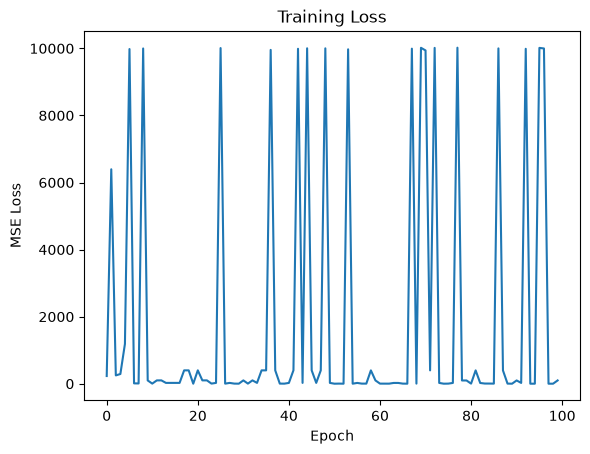

In [ ]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.show()

In [ ]:
loss_history = []

num_epochs = 100

for epoch in range(num_epochs):

    # Choose one of the 5 images
    image = images[np.random.randint(len(images))]

    # Choose a sigma
    sigma = float(np.random.choice(sigmas))

    # Add noise and calculate target score
    noisy_image, sigma, target_score = make_training_example(
        image,
        sigma
    )

    # Prepare input and target
    cnn_input = prepare_input(
        noisy_image,
        sigma
    )

    target_tensor = prepare_target(
        target_score
    )

    # Predict score
    predicted_score = model(cnn_input)

    # Calculate loss
    loss = loss_function(
        predicted_score,
        target_tensor
    )

    # Train
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Save loss
    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(
            "Epoch:", epoch,
            "Image:", images.index(image) if False else "random",
            "Sigma:", sigma,
            "Loss:", loss.item()
        )

Epoch: 0 Image: random Sigma: 0.01 Loss: 9958.0068359375
Epoch: 10 Image: random Sigma: 0.2 Loss: 21.49243927001953
Epoch: 20 Image: random Sigma: 0.05 Loss: 390.4610900878906
Epoch: 30 Image: random Sigma: 1.0 Loss: 7.153951644897461
Epoch: 40 Image: random Sigma: 0.1 Loss: 90.2289047241211
Epoch: 50 Image: random Sigma: 0.2 Loss: 23.07951545715332
Epoch: 60 Image: random Sigma: 0.2 Loss: 20.728099822998047
Epoch: 70 Image: random Sigma: 0.05 Loss: 372.5525207519531
Epoch: 80 Image: random Sigma: 0.5 Loss: 5.3025898933410645
Epoch: 90 Image: random Sigma: 0.01 Loss: 9935.005859375


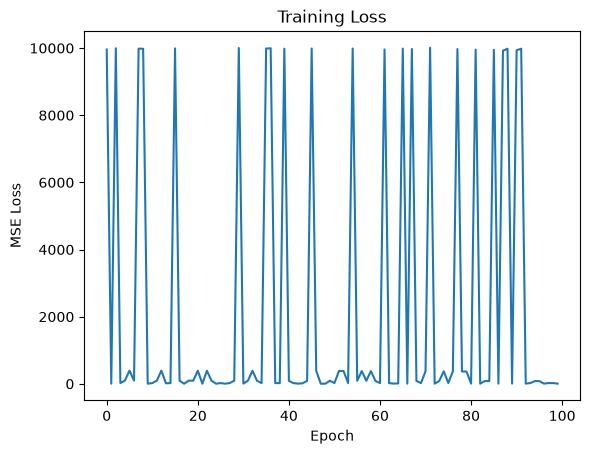

In [ ]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.show()

In [ ]:
sigma_test = 0.5

noisy_test, _, _ = make_training_example(
    images[0],
    sigma_test
)

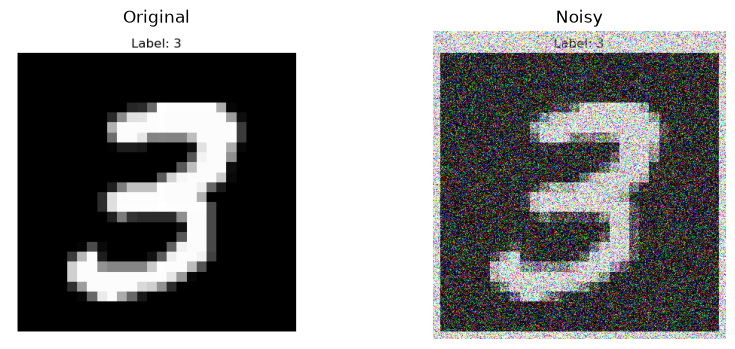

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.clip(images[0], 0, 1))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(noisy_test, 0, 1))
plt.title("Noisy")
plt.axis("off")

plt.show()

In [ ]:
cnn_input = prepare_input(
    noisy_test,
    sigma_test
)

with torch.no_grad():
    predicted_score = model(cnn_input)

In [ ]:
step_size = 0.001

denoised_tensor = cnn_input[:, :3, :, :] + step_size * predicted_score

In [ ]:
denoised = denoised_tensor.squeeze(0).permute(1, 2, 0).numpy()

denoised = np.clip(denoised, 0, 1)

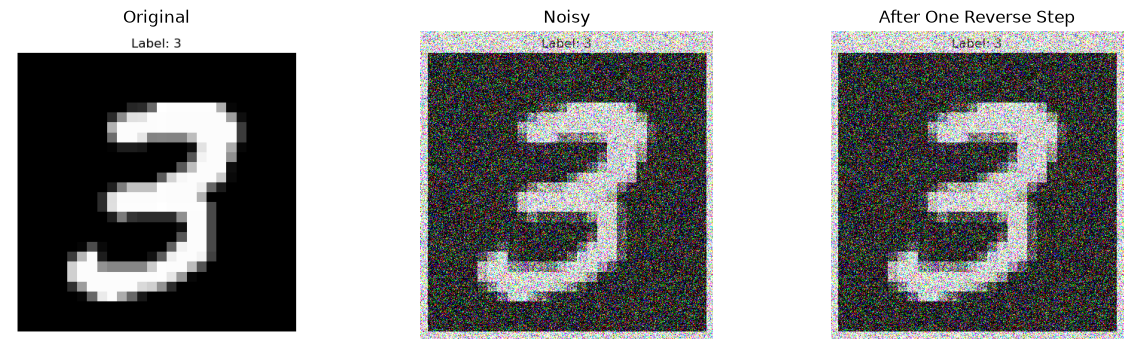

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.clip(images[0], 0, 1))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.clip(noisy_test, 0, 1))
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised)
plt.title("After One Reverse Step")
plt.axis("off")

plt.show()

In [ ]:
sigma_test = 0.5

noisy_test, _, _ = make_training_example(
    images[0],
    sigma_test
)

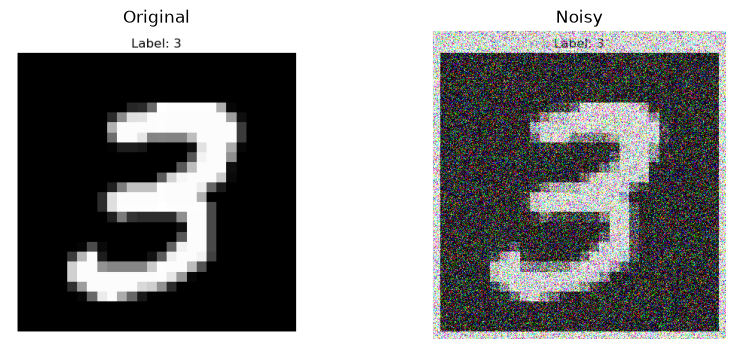

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.clip(images[0], 0, 1))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(noisy_test, 0, 1))
plt.title("Noisy")
plt.axis("off")

plt.show()

In [ ]:
cnn_input = prepare_input(
    noisy_test,
    sigma_test
)

with torch.no_grad():
    predicted_score = model(cnn_input)

print("Predicted score shape:", predicted_score.shape)

Predicted score shape: torch.Size([1, 3, 409, 389])


In [ ]:
step_size = 0.001

current_image = torch.tensor(
    noisy_test,
    dtype=torch.float32
)

current_image = current_image.permute(2, 0, 1)
current_image = current_image.unsqueeze(0)

denoised_tensor = (
    current_image
    + step_size * predicted_score
)

In [ ]:
denoised = (
    denoised_tensor
    .squeeze(0)
    .permute(1, 2, 0)
    .numpy()
)

denoised = np.clip(denoised, 0, 1)

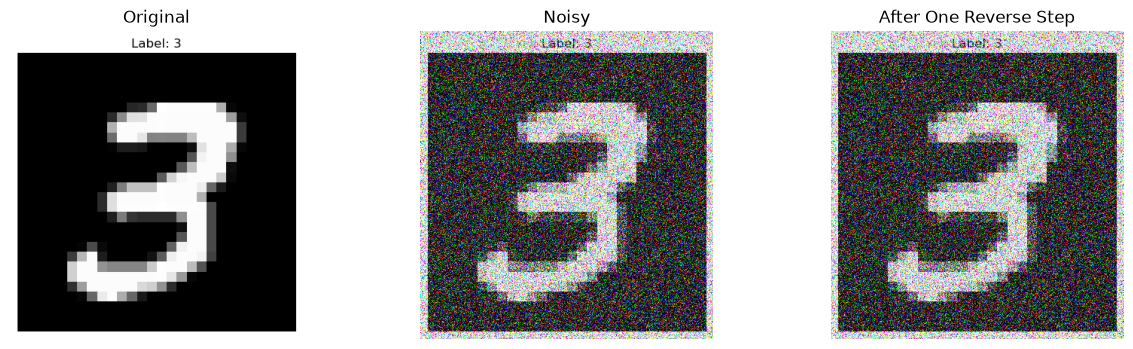

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.clip(images[0], 0, 1))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.clip(noisy_test, 0, 1))
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised)
plt.title("After One Reverse Step")
plt.axis("off")

plt.show()

In [ ]:
num_steps = 1000
step_size = 0.005

current_image = noisy_test.copy()

for step in range(num_steps):

    # Give the current image to the network
    cnn_input = prepare_input(
        current_image,
        sigma_test
    )

    # Predict the score
    with torch.no_grad():
        predicted_score = model(cnn_input)

    # Convert score to numpy
    predicted_score = (
        predicted_score
        .squeeze(0)
        .permute(1, 2, 0)
        .numpy()
    )

    # Take one reverse step
    current_image = (
        current_image
        + step_size * predicted_score
    )

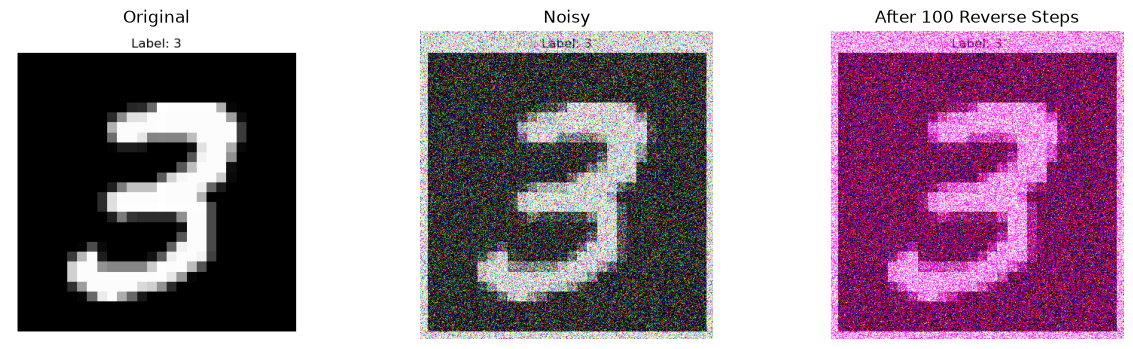

In [ ]:
recovered_image = np.clip(
    current_image,
    0,
    1
)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.clip(images[0], 0, 1), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.clip(noisy_test, 0, 1), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(recovered_image, cmap="gray")
plt.title("After 100 Reverse Steps")
plt.axis("off")

plt.show()